# Bangladesh Community Health Screening Dataset
## Deep Analysis & Preprocessing Pipeline

**Dataset:** `test-dataset.xlsx` — 29,999 rows × 34 columns  
**Domain:** Community health screening (demographic + clinical vitals)  
**Notebook sections:**
1. Setup & Load
2. Deep Exploratory Analysis
3. Missing Data Analysis
4. Outlier Detection
5. Data Quality Issues
6. Preprocessing Pipeline
7. Final Dataset Summary


## 1. Setup & Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams.update({'figure.figsize': (12, 5), 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_theme(style='whitegrid', palette='muted')

print('Libraries loaded successfully.')


Libraries loaded successfully.


In [2]:
# Load dataset — update path if needed
df_raw = pd.read_excel('test-dataset.xlsx')
df = df_raw.copy()

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')


Shape: 29,999 rows × 34 columns
Memory usage: 27.2 MB


In [3]:
# Quick peek
df.head(5)


,Unnamed: 0,household_id,total_income,union_name,user_id,profile_name,father_name,mother_name,birthday,age,gender,is_poor,is_freedom_fighter,had_stroke,has_cardiovascular_disease,disabilities_name,diabetic,profile_hypertensive,SYSTOLIC,DIASTOLIC,RESULT_STAT_BP,HEIGHT,WEIGHT,BMI,RESULT_STAT_BMI,SUGAR,TAG_NAME,RESULT_STAT_SUGAR,PULSE_RATE,RESULT_STAT_PR,SPO2,RESULT_STAT_SPO2,MUAC,RESULT_STAT_MUAC
0,1,241175,Lower class,KOLA,988794,মো: সাগরহোসেন,0.0,0.0,2001-11-05 18:00:00,19,Male,0,0,0,0,0,False,False,130.00,84.00,Prehypertension,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.00,Normal,97.00,Normal,NaN,NaN
1,2,241176,Lower class,KOLA,988796,মোছা:তামান্না,0.0,0.0,2000-06-18 18:00:00,20,Female,0,0,0,0,0,False,False,148.00,74.00,Mild High,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.00,Normal,NaN,NaN,NaN,NaN
2,3,241179,Lower class,KOLA,988802,শুকুরুচন্দ্র,0.0,0.0,1978-06-04 18:00:00,42,Male,0,0,0,0,0,False,False,121.00,75.00,Prehypertension,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.00,Normal,NaN,NaN,NaN,NaN
3,4,241180,Lower class,KOLA,988807,দিপালীরাণী,0.0,0.0,1956-02-02 18:00:00,64,Female,0,0,0,0,0,False,False,111.00,64.00,Normal,NaN,NaN,NaN,NaN,8.72,Random,Normal,85.00,Normal,NaN,NaN,NaN,NaN
4,5,241181,Lower class,KOLA,988809,বুলবুলি,0.0,0.0,1996-12-25 18:00:00,23,Female,0,0,0,0,0,False,False,123.00,66.00,Prehypertension,NaN,NaN,NaN,NaN,NaN,NaN,NaN,101.00,High,NaN,NaN,NaN,NaN


In [4]:
# Column names and dtypes
df.dtypes.to_frame('dtype').assign(non_null=df.count(), null=df.isnull().sum())


,dtype,non_null,null
Unnamed: 0,int64,29999,0
household_id,int64,29999,0
total_income,object,29999,0
union_name,object,29999,0
user_id,int64,29999,0
profile_name,object,29999,0
father_name,object,25561,4438
mother_name,object,25547,4452
birthday,object,29999,0
age,int64,29999,0


## 2. Deep Exploratory Data Analysis

### 2.1 Dataset shape & basic statistics

In [5]:
print('=== Numeric columns ===')
display(df.describe().T.round(2))


=== Numeric columns ===


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,29999.00,15000.00,8660.11,1.00,7500.50,15000.00,22499.50,29999.00
household_id,29999.00,220657.30,158927.21,12300.00,81244.50,219654.00,279809.50,786118.00
user_id,29999.00,978483.29,808133.04,96804.00,351611.00,905099.00,1122635.00,4040559.00
age,29999.00,38.64,17.49,0.00,26.00,37.00,50.00,120.00
is_poor,29999.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
is_freedom_fighter,29999.00,0.00,0.01,0.00,0.00,0.00,0.00,1.00
had_stroke,29999.00,0.00,0.03,0.00,0.00,0.00,0.00,1.00
has_cardiovascular_disease,29999.00,0.00,0.03,0.00,0.00,0.00,0.00,1.00
SYSTOLIC,27600.00,122.16,20.86,52.00,107.00,120.00,132.00,227.00
DIASTOLIC,27600.00,76.13,12.28,30.00,68.00,75.00,83.00,144.00


In [6]:
print('=== Categorical columns ===')
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
display(df[cat_cols].describe().T)


=== Categorical columns ===


,count,unique,top,freq
total_income,29999,4,Lower class,19975
union_name,29999,16,CHERAGPUR,6227
profile_name,29999,17168,মনোয়ারাবেগম,77
father_name,25561,4710,0,17143
mother_name,25547,3701,0,16583
birthday,29999,22828,1985-03-10 00:00:00,36
gender,29999,2,Female,23236
disabilities_name,29999,6,0,29930
diabetic,29999,2,False,29398
profile_hypertensive,29999,2,False,28424


### 2.2 Unique value counts

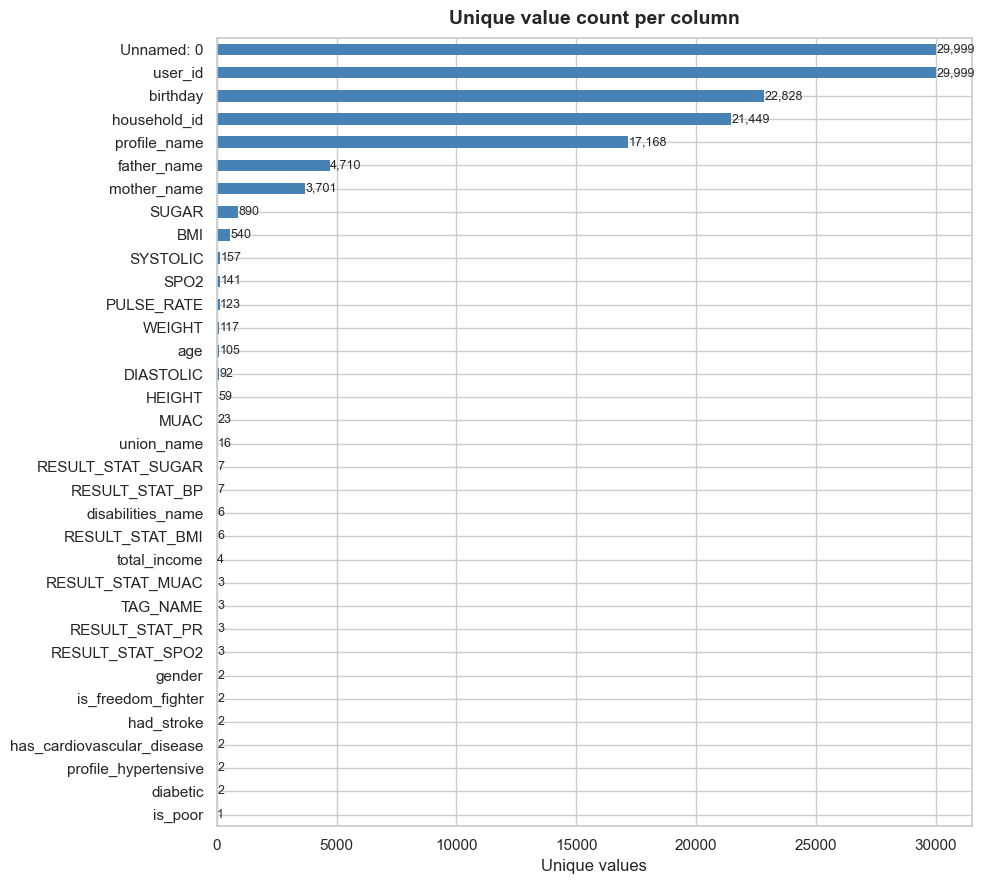

In [7]:
unique_counts = df.nunique().sort_values()
fig, ax = plt.subplots(figsize=(10, 9))
unique_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Unique value count per column', fontsize=14, fontweight='bold', pad=10)
ax.set_xlabel('Unique values')
for bar in ax.patches:
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


### 2.3 Categorical distribution plots

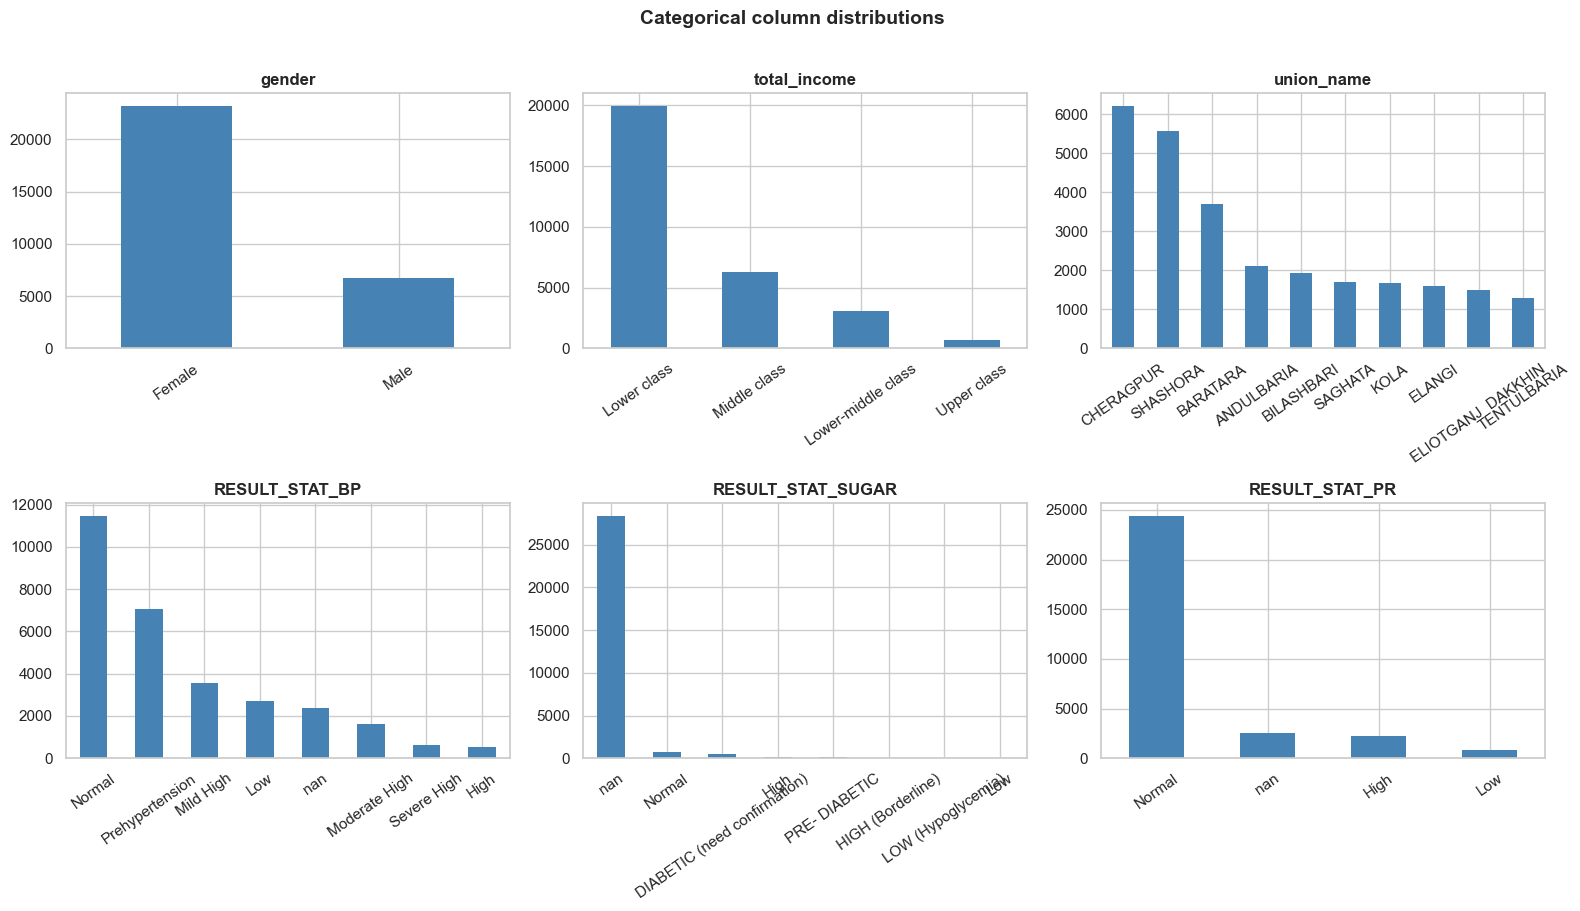

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

cat_plot_cols = ['gender', 'total_income', 'union_name', 'RESULT_STAT_BP',
                 'RESULT_STAT_SUGAR', 'RESULT_STAT_PR']

for i, col in enumerate(cat_plot_cols):
    vc = df[col].value_counts(dropna=False).head(10)
    vc.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='none')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=35)

plt.suptitle('Categorical column distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 2.4 Numeric distributions

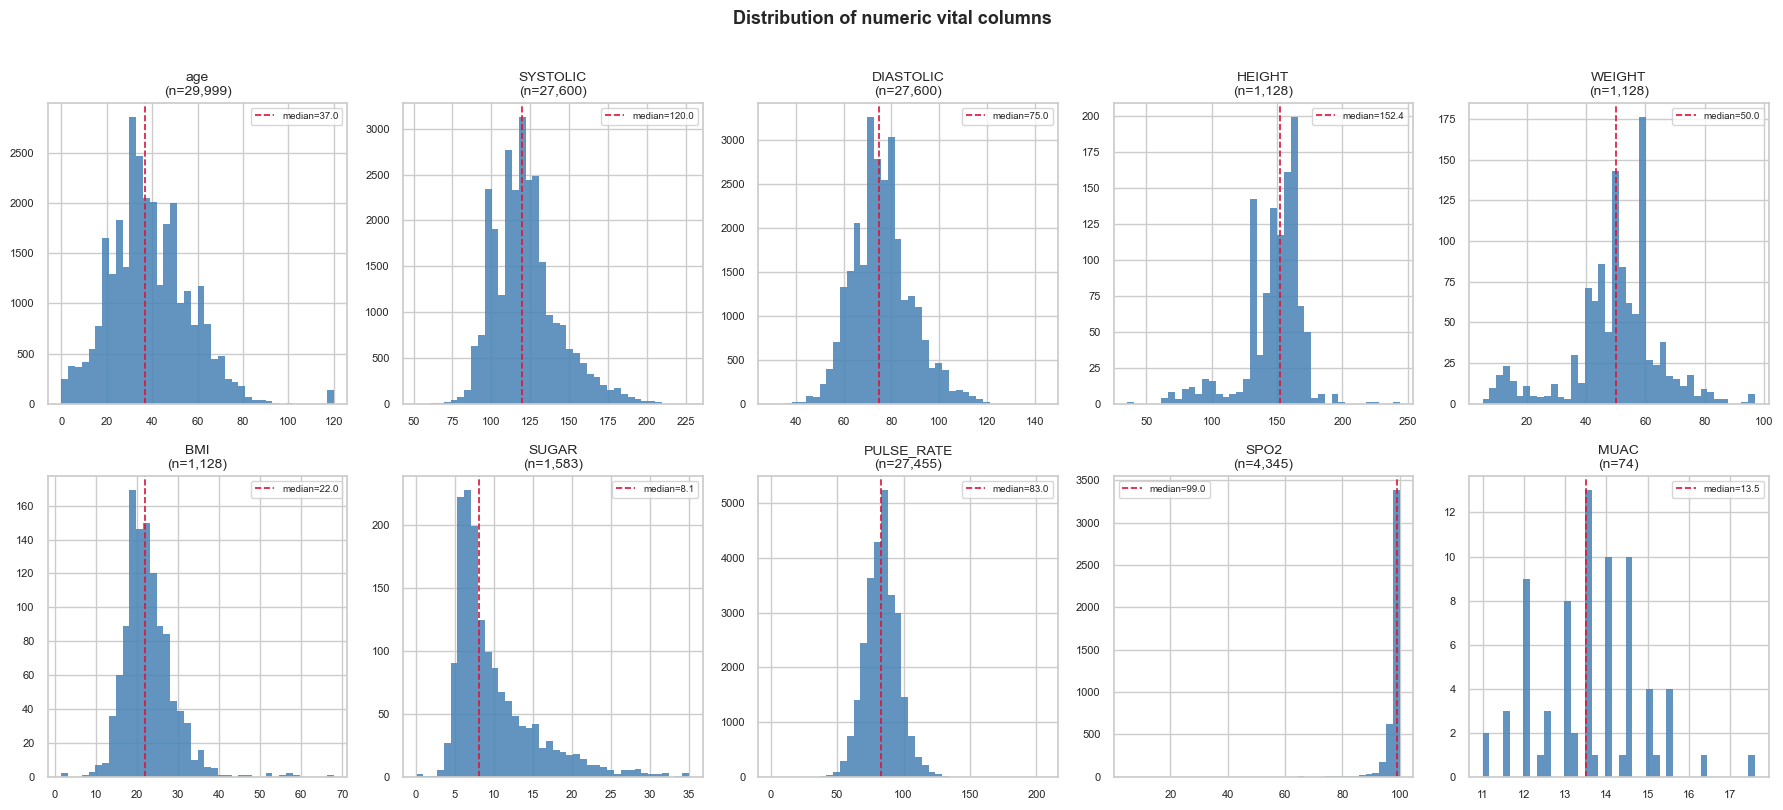

In [9]:
numeric_vitals = ['age', 'SYSTOLIC', 'DIASTOLIC', 'HEIGHT', 'WEIGHT',
                  'BMI', 'SUGAR', 'PULSE_RATE', 'SPO2', 'MUAC']

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_vitals):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='steelblue', edgecolor='none', alpha=0.85)
    axes[i].set_title(f'{col}\n(n={len(data):,})', fontsize=10)
    axes[i].axvline(data.median(), color='crimson', linewidth=1.2, linestyle='--', label=f'median={data.median():.1f}')
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=8)

plt.suptitle('Distribution of numeric vital columns', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 2.5 Gender breakdown across clinical results

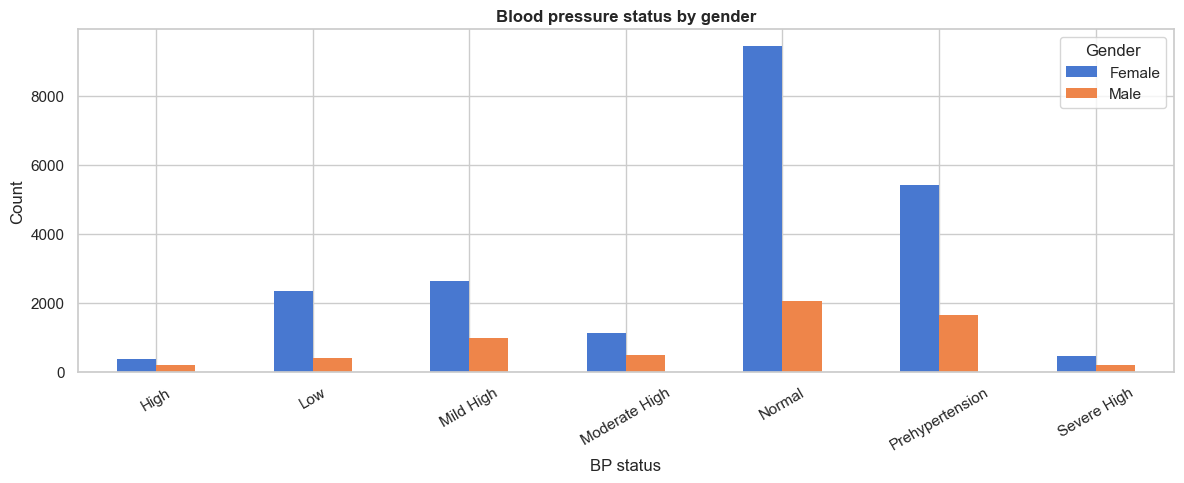

In [10]:
bp_gender = df.groupby(['gender', 'RESULT_STAT_BP']).size().unstack(fill_value=0)
bp_gender.T.plot(kind='bar', figsize=(12, 5), edgecolor='none')
plt.title('Blood pressure status by gender', fontweight='bold')
plt.xlabel('BP status')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


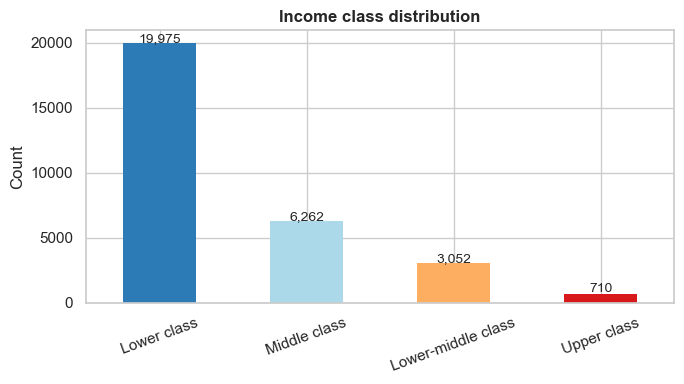

In [11]:
# Income class distribution
vc = df['total_income'].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
vc.plot(kind='bar', ax=ax, color=['#2c7bb6','#abd9e9','#fdae61','#d7191c'], edgecolor='none')
ax.set_title('Income class distribution', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=20)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{int(bar.get_height()):,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


## 3. Missing Data Analysis

In [12]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(f'Columns with missing values: {len(missing_df)}')
print(f'Total missing cells: {missing.sum():,}  ({missing.mean()*100:.2f}% of all cells)')
display(missing_df)


Columns with missing values: 18
Total missing cells: 333,065  (979602.94% of all cells)


,missing_count,missing_pct
RESULT_STAT_MUAC,29925,99.75
MUAC,29925,99.75
RESULT_STAT_BMI,28871,96.24
HEIGHT,28871,96.24
WEIGHT,28871,96.24
BMI,28871,96.24
RESULT_STAT_SUGAR,28416,94.72
TAG_NAME,28416,94.72
SUGAR,28416,94.72
SPO2,25654,85.52


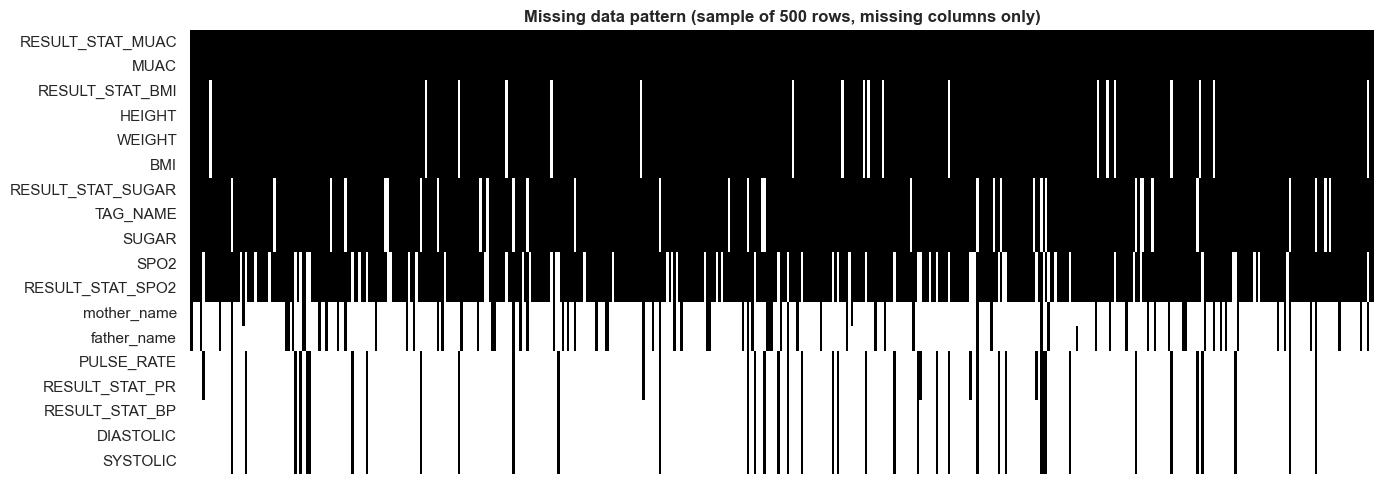

In [13]:
# Heatmap of missing data pattern
plt.figure(figsize=(14, 5))
missing_cols = missing_df.index.tolist()
sns.heatmap(df[missing_cols].isnull().sample(min(500, len(df)), random_state=42).T,
            cbar=False, cmap='binary', yticklabels=True, xticklabels=False)
plt.title('Missing data pattern (sample of 500 rows, missing columns only)', fontweight='bold')
plt.tight_layout()
plt.show()


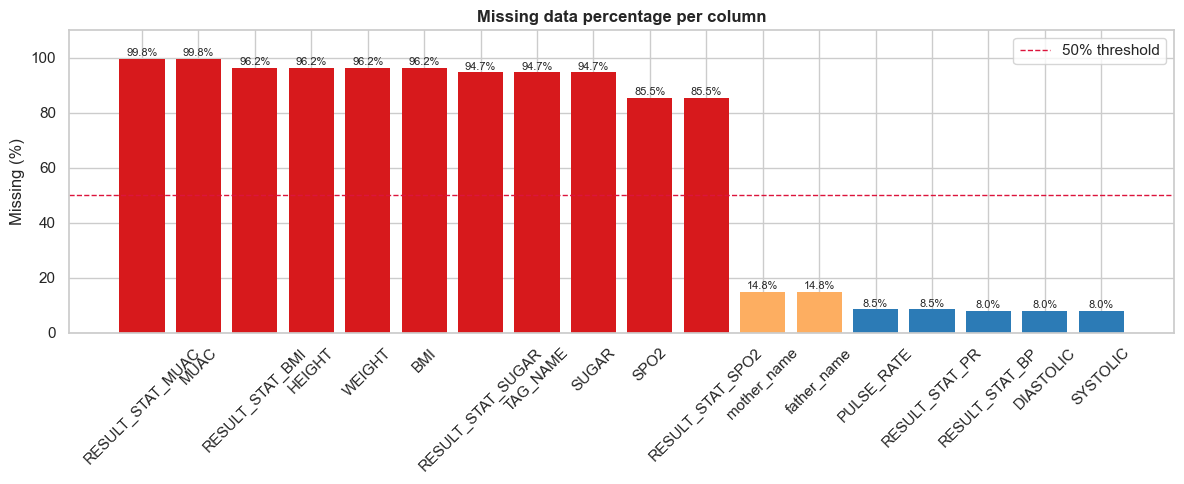

In [14]:
# Bar chart: missing percentage by column
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#d7191c' if p > 50 else '#fdae61' if p > 10 else '#2c7bb6'
          for p in missing_df['missing_pct']]
bars = ax.bar(missing_df.index, missing_df['missing_pct'], color=colors, edgecolor='none')
ax.axhline(50, color='crimson', linestyle='--', linewidth=1, label='50% threshold')
ax.set_title('Missing data percentage per column', fontweight='bold')
ax.set_ylabel('Missing (%)')
ax.set_ylim(0, 110)
ax.tick_params(axis='x', rotation=45)
for bar, pct in zip(bars, missing_df['missing_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{pct:.1f}%', ha='center', fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()


In [15]:
# Co-missingness: check if HEIGHT/WEIGHT/BMI are always missing together
print('Are HEIGHT, WEIGHT, BMI always missing together?')
mask_h = df['HEIGHT'].isnull()
mask_w = df['WEIGHT'].isnull()
mask_b = df['BMI'].isnull()
print(f'  HEIGHT missing: {mask_h.sum():,}')
print(f'  WEIGHT missing: {mask_w.sum():,}')
print(f'  BMI missing:    {mask_b.sum():,}')
print(f'  All three same rows: {(mask_h == mask_w).all() and (mask_w == mask_b).all()}')

print('\nAre SUGAR/TAG_NAME/RESULT_STAT_SUGAR always missing together?')
mask_s = df['SUGAR'].isnull()
mask_t = df['TAG_NAME'].isnull()
print(f'  Same rows: {(mask_s == mask_t).all()}')


Are HEIGHT, WEIGHT, BMI always missing together?
  HEIGHT missing: 28,871
  WEIGHT missing: 28,871
  BMI missing:    28,871
  All three same rows: True

Are SUGAR/TAG_NAME/RESULT_STAT_SUGAR always missing together?
  Same rows: True


## 4. Outlier Detection

### 4.1 IQR-based outlier summary

In [16]:
outlier_summary = []
numeric_cols = ['age', 'SYSTOLIC', 'DIASTOLIC', 'HEIGHT', 'WEIGHT',
                'BMI', 'SUGAR', 'PULSE_RATE', 'SPO2', 'MUAC']

for col in numeric_cols:
    s = df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((s < lower) | (s > upper)).sum()
    outlier_summary.append({
        'column': col, 'n_valid': len(s),
        'min': s.min(), 'max': s.max(),
        'IQR_lower': round(lower, 2), 'IQR_upper': round(upper, 2),
        'n_outliers': n_out, 'outlier_pct': round(n_out/len(s)*100, 2)
    })

out_df = pd.DataFrame(outlier_summary)
display(out_df)


,column,n_valid,min,max,IQR_lower,IQR_upper,n_outliers,outlier_pct
0,age,29999,0.00,120.00,-10.00,86.00,212,0.71
1,SYSTOLIC,27600,52.00,227.00,69.50,169.50,922,3.34
2,DIASTOLIC,27600,30.00,144.00,45.50,105.50,628,2.28
3,HEIGHT,1128,35.56,243.84,99.06,200.66,65,5.76
4,WEIGHT,1128,5.00,97.00,21.50,81.50,101,8.95
5,BMI,1128,1.58,67.93,8.61,36.11,26,2.30
6,SUGAR,1583,0.11,35.00,-1.92,20.29,93,5.87
7,PULSE_RATE,27455,1.00,206.00,49.50,117.50,265,0.97
8,SPO2,4345,5.00,100.00,96.50,100.50,683,15.72
9,MUAC,74,11.00,17.60,10.75,16.75,1,1.35


### 4.2 Box plots for vital signs

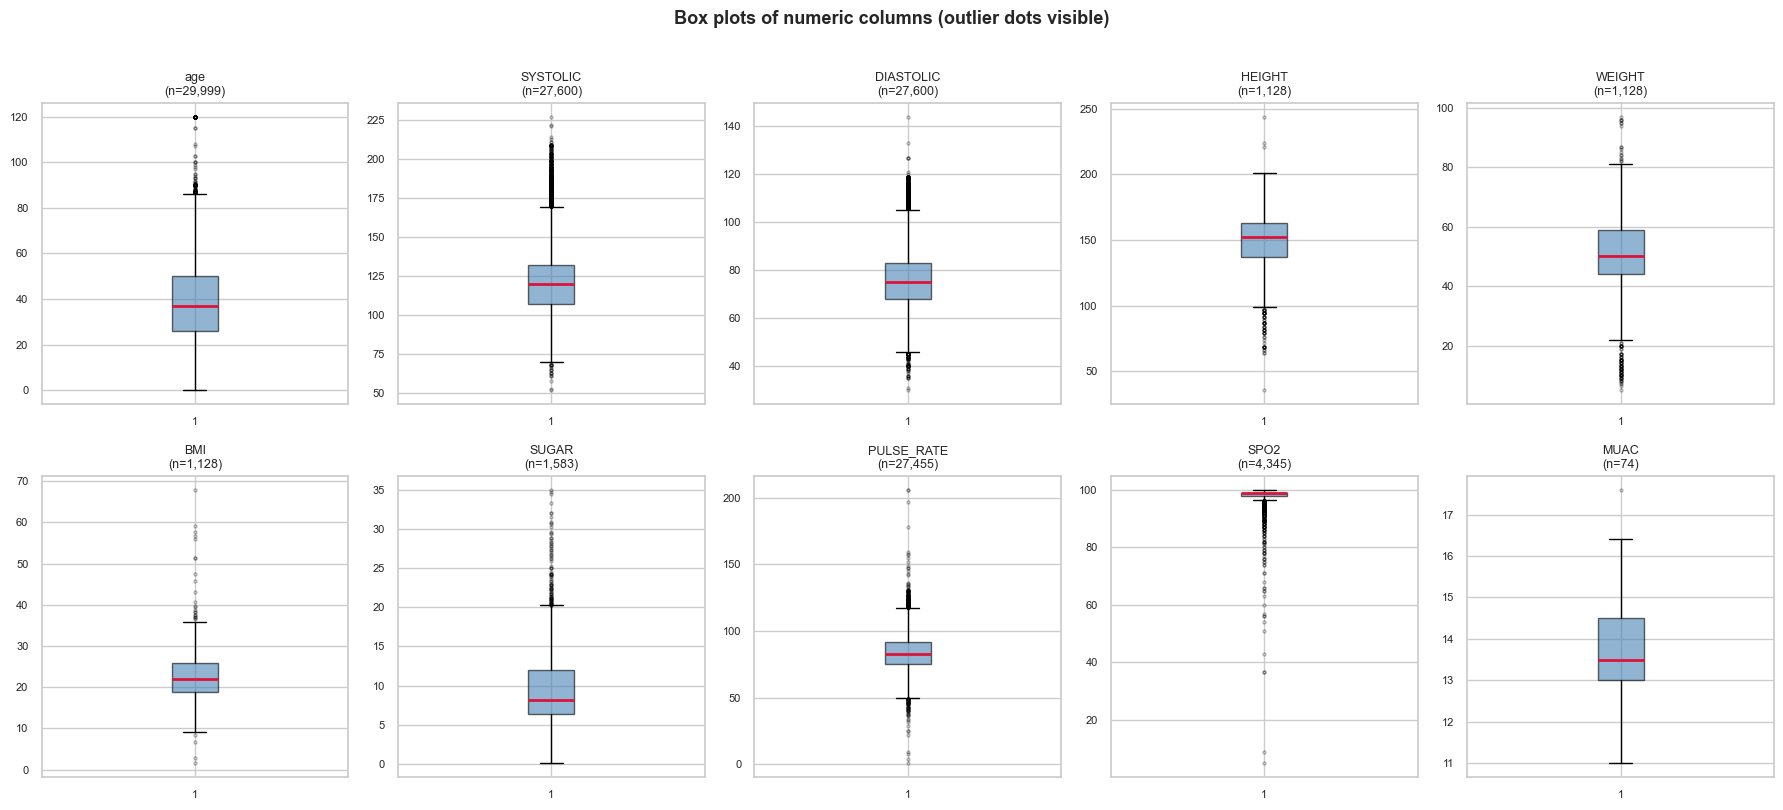

In [17]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
    axes[i].boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='crimson', linewidth=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3, color='gray'))
    axes[i].set_title(f'{col}\n(n={len(data):,})', fontsize=9)
    axes[i].tick_params(labelsize=8)

plt.suptitle('Box plots of numeric columns (outlier dots visible)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 4.3 Clinical validity checks

In [18]:
print('=== Clinically implausible values ===\n')

checks = [
    ('age == 0',             df['age'] == 0),
    ('age > 100',            df['age'] > 100),
    ('age == 120',           df['age'] == 120),
    ('SYSTOLIC < 60',        df['SYSTOLIC'] < 60),
    ('SYSTOLIC > 220',       df['SYSTOLIC'] > 220),
    ('DIASTOLIC < 30',       df['DIASTOLIC'] < 30),
    ('DIASTOLIC > 130',      df['DIASTOLIC'] > 130),
    ('PULSE_RATE < 30',      df['PULSE_RATE'] < 30),
    ('PULSE_RATE > 200',     df['PULSE_RATE'] > 200),
    ('SPO2 < 70',            df['SPO2'] < 70),
    ('HEIGHT < 50 cm',       df['HEIGHT'] < 50),
    ('HEIGHT > 230 cm',      df['HEIGHT'] > 230),
    ('WEIGHT < 15 kg',       df['WEIGHT'] < 15),
    ('BMI < 10',             df['BMI'] < 10),
    ('BMI > 60',             df['BMI'] > 60),
    ('SUGAR < 1 mmol/L',     df['SUGAR'] < 1),
]

for label, mask in checks:
    count = mask.sum()
    if count > 0:
        print(f'  {label:35s}: {count:5,} rows')


=== Clinically implausible values ===

  age == 0                           :    25 rows
  age > 100                          :   140 rows
  age == 120                         :   134 rows
  SYSTOLIC < 60                      :     3 rows
  SYSTOLIC > 220                     :     3 rows
  DIASTOLIC > 130                    :     2 rows
  PULSE_RATE < 30                    :     8 rows
  PULSE_RATE > 200                   :     2 rows
  SPO2 < 70                          :    17 rows
  HEIGHT < 50 cm                     :     1 rows
  HEIGHT > 230 cm                    :     1 rows
  WEIGHT < 15 kg                     :    55 rows
  BMI < 10                           :     6 rows
  BMI > 60                           :     1 rows
  SUGAR < 1 mmol/L                   :     2 rows


## 5. Data Quality Issues

### 5.1 Constant column: is_poor

In [19]:
print('Unique values in is_poor:', df['is_poor'].unique())
print('Value counts:\n', df['is_poor'].value_counts())
print('\nConclusion: Zero variance — this column carries no information.')


Unique values in is_poor: [0]
Value counts:
 is_poor
0    29999
Name: count, dtype: int64

Conclusion: Zero variance — this column carries no information.


### 5.2 Age vs birthday mismatch

In [20]:
df['birthday_parsed'] = pd.to_datetime(df['birthday'], errors='coerce')
# Strip time component — normalize to date
df['birthday_date'] = df['birthday_parsed'].dt.normalize()

# Compute age from birthday using a reference date (approximate data collection year)
# The stored age is ~6 years behind the current date, suggesting collection ~2019
reference_date = pd.Timestamp('2020-01-01')
df['computed_age'] = ((reference_date - df['birthday_date']).dt.days / 365.25).apply(
    lambda x: round(x) if pd.notnull(x) else np.nan)

df['age_diff'] = (df['computed_age'] - df['age']).abs()

print(f'Rows with age vs birthday mismatch > 2 years: {(df["age_diff"] > 2).sum():,}')
print(f'Mean absolute difference: {df["age_diff"].mean():.1f} years')
print('\nSample rows with mismatch:')
display(df[df['age_diff'] > 2][['birthday', 'age', 'computed_age', 'age_diff']].head(8))


Rows with age vs birthday mismatch > 2 years: 0
Mean absolute difference: 0.2 years

Sample rows with mismatch:


,birthday,age,computed_age,age_diff


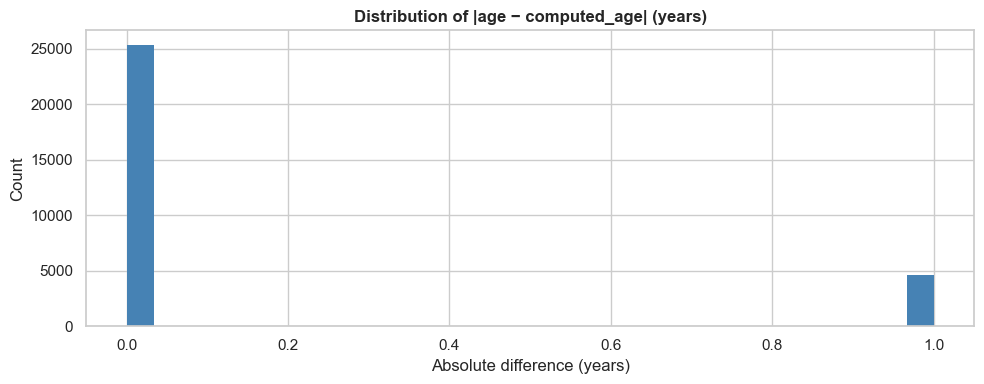

In [21]:
# Distribution of age differences
fig, ax = plt.subplots(figsize=(10, 4))
df['age_diff'].dropna().hist(bins=30, ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Distribution of |age − computed_age| (years)', fontweight='bold')
ax.set_xlabel('Absolute difference (years)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


### 5.3 Name placeholder zeros

In [22]:
for col in ['father_name', 'mother_name']:
    true_nan    = df[col].isnull().sum()
    zero_str    = (df[col] == '0').sum()
    zero_float  = (df[col] == '0.0').sum()
    valid       = len(df) - true_nan - zero_str - zero_float
    print(f'{col}:')
    print(f'  True NaN     : {true_nan:,}')
    print(f'  "0" string   : {zero_str:,}')
    print(f'  "0.0" string : {zero_float:,}')
    print(f'  Effectively invalid: {true_nan + zero_str + zero_float:,} / {len(df):,}'
          f'  ({(true_nan+zero_str+zero_float)/len(df)*100:.1f}%)')
    print(f'  Real values  : {valid:,}')
    print()


father_name:
  True NaN     : 4,438
  "0" string   : 17,143
  "0.0" string : 766
  Effectively invalid: 22,347 / 29,999  (74.5%)
  Real values  : 7,652

mother_name:
  True NaN     : 4,452
  "0" string   : 16,583
  "0.0" string : 1,333
  Effectively invalid: 22,368 / 29,999  (74.6%)
  Real values  : 7,631



### 5.4 Birthday timezone inconsistency

Top time-of-day values in birthday field (should all be 00:00:00):
birthday_parsed
18:00:00    10406
00:00:00     3985
17:30:00      391
18:30:00      146
18:06:40      121
00:25:46       68
17:29:32       58
17:29:33       57
17:36:39       49
00:21:50       48


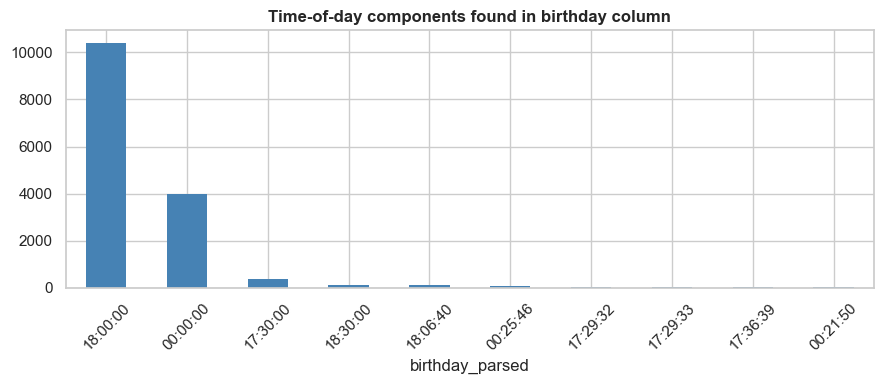

In [23]:
# Birthday has mixed time components — indicates multiple data collection tools
time_parts = df['birthday_parsed'].dt.strftime('%H:%M:%S').value_counts().head(10)
print('Top time-of-day values in birthday field (should all be 00:00:00):')
print(time_parts.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
time_parts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Time-of-day components found in birthday column', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


### 5.5 Boolean encoding inconsistency

In [24]:
print('diabetic dtype:', df['diabetic'].dtype, '— values:', df['diabetic'].unique())
print('profile_hypertensive dtype:', df['profile_hypertensive'].dtype, '— values:', df['profile_hypertensive'].unique())
print('had_stroke dtype:', df['had_stroke'].dtype, '— values:', df['had_stroke'].unique())
print('has_cardiovascular_disease dtype:', df['has_cardiovascular_disease'].dtype, '— values:', df['has_cardiovascular_disease'].unique())
print('\nConclusion: diabetic/hypertensive use True/False; stroke/CVD use 0/1 — inconsistent encoding.')


diabetic dtype: bool — values: [False  True]
profile_hypertensive dtype: bool — values: [False  True]
had_stroke dtype: int64 — values: [0 1]
has_cardiovascular_disease dtype: int64 — values: [0 1]

Conclusion: diabetic/hypertensive use True/False; stroke/CVD use 0/1 — inconsistent encoding.


### 5.6 Ordinal encoding needed: total_income

In [25]:
print('total_income unique values:', df['total_income'].unique())
income_order = ['Lower class', 'Lower-middle class', 'Middle class', 'Upper class']
print('Natural ordinal order (0→3):', income_order)


total_income unique values: ['Lower class' 'Lower-middle class' 'Upper class' 'Middle class']
Natural ordinal order (0→3): ['Lower class', 'Lower-middle class', 'Middle class', 'Upper class']


### 5.7 disabilities_name sentinel zeros

In [26]:
print('disabilities_name value counts:')
print(df['disabilities_name'].value_counts(dropna=False))
print('\nConclusion: "0" is a placeholder for no disability. Should be NaN or "None".')


disabilities_name value counts:
disabilities_name
0           29930
physical       25
eye            17
others         16
mental          7
ear             4
Name: count, dtype: int64

Conclusion: "0" is a placeholder for no disability. Should be NaN or "None".


### 5.8 Correlation heatmap (numeric columns)

Rows with all numeric vitals present: 10


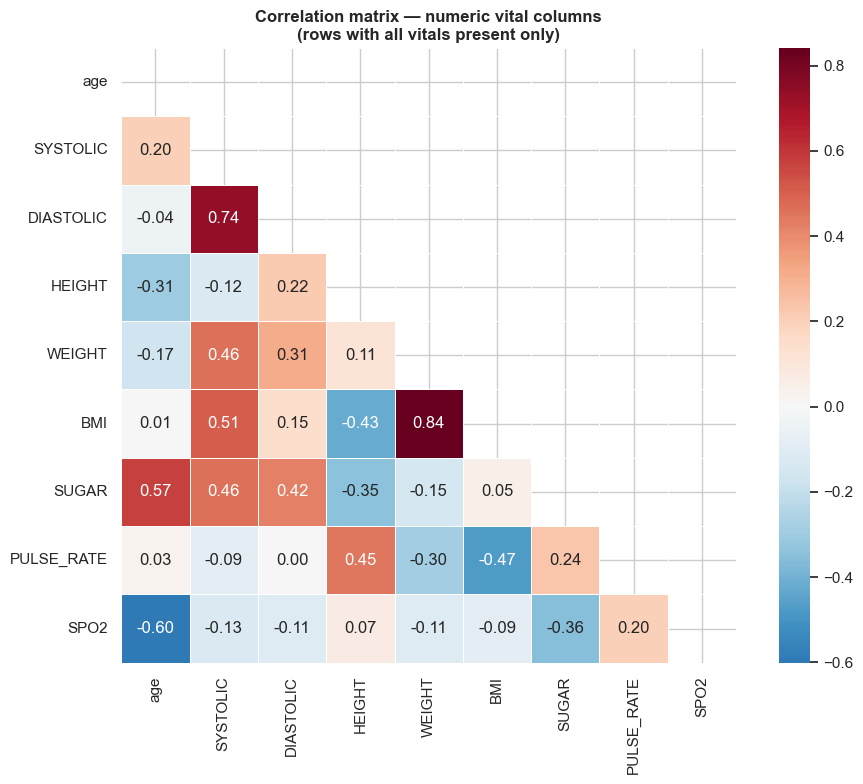

In [27]:
num_df = df[['age', 'SYSTOLIC', 'DIASTOLIC', 'HEIGHT', 'WEIGHT',
             'BMI', 'SUGAR', 'PULSE_RATE', 'SPO2']].dropna(how='any')
print(f'Rows with all numeric vitals present: {len(num_df):,}')

corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, square=True)
ax.set_title('Correlation matrix — numeric vital columns\n(rows with all vitals present only)',
             fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Preprocessing Pipeline

Applying all identified fixes in a clean, reproducible pipeline.

In [28]:
# Start from original raw data
df_clean = df_raw.copy()

print('Starting shape:', df_clean.shape)


Starting shape: (29999, 34)


### Step 1: Drop useless columns

In [29]:
# Drop: redundant index, constant column, near-completely-missing columns, PII names
drop_cols = [
    'Unnamed: 0',          # redundant sequential index
    'is_poor',             # zero variance (always 0)
    'MUAC',                # 99.75% missing
    'RESULT_STAT_MUAC',    # 99.75% missing
    'profile_name',        # PII, no predictive value
    'father_name',         # PII, ~73% effectively missing
    'mother_name',         # PII, ~73% effectively missing
]

df_clean = df_clean.drop(columns=drop_cols)
print(f'After dropping useless columns: {df_clean.shape}')


After dropping useless columns: (29999, 27)


### Step 2: Fix birthday — strip time, recompute age

In [30]:
# Parse birthday, normalize to date only (remove spurious time components)
df_clean['birthday'] = pd.to_datetime(df_clean['birthday'], errors='coerce').dt.normalize()

# Recompute age using reference date 2020-01-01 (approximate collection period)
# Change this to the actual survey date if known
REFERENCE_DATE = pd.Timestamp('2020-01-01')
df_clean['age'] = ((REFERENCE_DATE - df_clean['birthday']).dt.days / 365.25).round().astype('Int64')

print('Age stats after recomputation:')
print(df_clean['age'].describe())


Age stats after recomputation:
count   29999.00
mean       38.51
std        17.49
min        -1.00
25%        26.00
50%        37.00
75%        50.00
max       120.00
Name: age, dtype: Float64


### Step 3: Remove biologically impossible ages

In [31]:
n_before = len(df_clean)

# Remove age = 0 (likely entry error in adult screening) and age > 100
age_mask = (df_clean['age'] > 0) & (df_clean['age'] <= 100)
df_clean = df_clean[age_mask].copy()

print(f'Rows removed (impossible age): {n_before - len(df_clean):,}')
print(f'Remaining rows: {len(df_clean):,}')
print('Age range after filter:', df_clean['age'].min(), '–', df_clean['age'].max())


Rows removed (impossible age): 188
Remaining rows: 29,811
Age range after filter: 1 – 100


### Step 4: Clip clinical vital signs to plausible ranges

In [32]:
vital_clips = {
    'SYSTOLIC':   (60,  220),
    'DIASTOLIC':  (40,  130),
    'PULSE_RATE': (30,  200),
    'SPO2':       (70,  100),
    'HEIGHT':     (50,  230),
    'WEIGHT':     (15,  150),
    'BMI':        (10,   60),
    'SUGAR':      (1.0,  35),
}

clipped_counts = {}
for col, (lo, hi) in vital_clips.items():
    if col not in df_clean.columns:
        continue
    n_before_clip = df_clean[col].between(lo, hi, inclusive='both').sum()
    df_clean[col] = df_clean[col].clip(lower=lo, upper=hi)
    n_after_clip  = df_clean[col].between(lo, hi, inclusive='both').sum()
    clipped_counts[col] = (df_clean[col].notna().sum() - n_before_clip)

print('Values clipped to plausible range:')
for col, (lo, hi) in vital_clips.items():
    if col in df_clean.columns:
        print(f'  {col:15s}: clipped to [{lo}, {hi}]')


Values clipped to plausible range:
  SYSTOLIC       : clipped to [60, 220]
  DIASTOLIC      : clipped to [40, 130]
  PULSE_RATE     : clipped to [30, 200]
  SPO2           : clipped to [70, 100]
  HEIGHT         : clipped to [50, 230]
  WEIGHT         : clipped to [15, 150]
  BMI            : clipped to [10, 60]
  SUGAR          : clipped to [1.0, 35]


### Step 5: Clean disabilities_name sentinel zeros

In [33]:
# Replace placeholder "0" with NaN (no disability recorded)
df_clean['disabilities_name'] = df_clean['disabilities_name'].replace({'0': np.nan, 0: np.nan})

print('disabilities_name after cleaning:')
print(df_clean['disabilities_name'].value_counts(dropna=False))


disabilities_name after cleaning:
disabilities_name
NaN         29743
physical       25
eye            17
others         15
mental          7
ear             4
Name: count, dtype: int64


### Step 6: Ordinal-encode total_income

In [34]:
income_order = ['Lower class', 'Lower-middle class', 'Middle class', 'Upper class']
income_map = {v: i for i, v in enumerate(income_order)}
df_clean['total_income_encoded'] = df_clean['total_income'].map(income_map)

print('Income encoding mapping:', income_map)
print('Encoded value counts:')
print(df_clean['total_income_encoded'].value_counts().sort_index())


Income encoding mapping: {'Lower class': 0, 'Lower-middle class': 1, 'Middle class': 2, 'Upper class': 3}
Encoded value counts:
total_income_encoded
0    19832
1     3044
2     6226
3      709
Name: count, dtype: int64


### Step 7: Standardize boolean encoding to 0/1

In [35]:
bool_cols = ['diabetic', 'profile_hypertensive']
for col in bool_cols:
    df_clean[col] = df_clean[col].astype(int)

print('Boolean columns converted to int (0/1):')
for col in bool_cols + ['had_stroke', 'has_cardiovascular_disease']:
    print(f'  {col}: {df_clean[col].unique()}')


Boolean columns converted to int (0/1):
  diabetic: [0 1]
  profile_hypertensive: [0 1]
  had_stroke: [0 1]
  has_cardiovascular_disease: [0 1]


### Step 8: Encode gender as binary

In [36]:
df_clean['gender_encoded'] = (df_clean['gender'] == 'Female').astype(int)
print('gender_encoded: 0=Male, 1=Female')
print(df_clean['gender_encoded'].value_counts())


gender_encoded: 0=Male, 1=Female
gender_encoded
1    23101
0     6710
Name: count, dtype: int64


### Step 9: Standardize RESULT_STAT_SUGAR labels

In [37]:
sugar_label_map = {
    'DIABETIC (need confirmation)': 'Diabetic (unconfirmed)',
    'PRE- DIABETIC':                'Pre-diabetic',
    'HIGH (Borderline)':            'High (borderline)',
    'LOW (Hypoglycemia)':           'Low (hypoglycemia)',
    'High':                         'High',
    'Low':                          'Low',
    'Normal':                       'Normal',
}
df_clean['RESULT_STAT_SUGAR'] = df_clean['RESULT_STAT_SUGAR'].map(sugar_label_map)

print('Standardized RESULT_STAT_SUGAR values:')
print(df_clean['RESULT_STAT_SUGAR'].value_counts(dropna=False))


Standardized RESULT_STAT_SUGAR values:
RESULT_STAT_SUGAR
NaN                       28233
Normal                      747
Diabetic (unconfirmed)      495
High                        178
Pre-diabetic                101
High (borderline)            39
Low (hypoglycemia)           16
Low                           2
Name: count, dtype: int64


### Step 10: Add missingness indicator columns for sparse vitals

In [38]:
# Columns with high missingness — add binary indicator before any imputation
# so models can learn whether a measurement was taken
sparse_cols = ['HEIGHT', 'WEIGHT', 'BMI', 'SUGAR', 'SPO2']
for col in sparse_cols:
    if col in df_clean.columns:
        df_clean[f'{col}_measured'] = df_clean[col].notna().astype(int)

print('Missingness indicator columns added:')
for col in sparse_cols:
    ind_col = f'{col}_measured'
    if ind_col in df_clean.columns:
        print(f'  {ind_col}: {df_clean[ind_col].sum():,} rows with measurement')


Missingness indicator columns added:
  HEIGHT_measured: 1,126 rows with measurement
  WEIGHT_measured: 1,126 rows with measurement
  BMI_measured: 1,126 rows with measurement
  SUGAR_measured: 1,578 rows with measurement
  SPO2_measured: 4,314 rows with measurement


### Step 11: Impute moderate-missingness vital columns

In [39]:
# Blood pressure and pulse rate (~8% missing) — impute with median per gender
moderate_miss = ['SYSTOLIC', 'DIASTOLIC', 'PULSE_RATE']

for col in moderate_miss:
    medians = df_clean.groupby('gender')[col].median()
    for gender_val, median_val in medians.items():
        mask = df_clean['gender'] == gender_val
        df_clean.loc[mask & df_clean[col].isnull(), col] = median_val
    # Remaining NaN (if gender was missing) — fill with overall median
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print('Imputation complete for:', moderate_miss)
for col in moderate_miss:
    print(f'  {col}: {df_clean[col].isnull().sum()} remaining NaN')


Imputation complete for: ['SYSTOLIC', 'DIASTOLIC', 'PULSE_RATE']
  SYSTOLIC: 0 remaining NaN
  DIASTOLIC: 0 remaining NaN
  PULSE_RATE: 0 remaining NaN


### Step 12: Add age group feature

In [40]:
bins  = [0, 17, 30, 45, 60, 100]
labels = ['Child/Teen', 'Young adult', 'Middle-aged', 'Senior', 'Elderly']
df_clean['age_group'] = pd.cut(df_clean['age'], bins=bins, labels=labels, right=True)

print('Age group distribution:')
print(df_clean['age_group'].value_counts().sort_index())


Age group distribution:
age_group
Child/Teen      2759
Young adult     7224
Middle-aged    10575
Senior          6323
Elderly         2930
Name: count, dtype: int64


### Step 13: Recompute RESULT_STAT_BP from cleaned BP values

In [41]:
def classify_bp(row):
    s = row['SYSTOLIC']
    d = row['DIASTOLIC']
    if pd.isnull(s) or pd.isnull(d):
        return np.nan
    if s < 90 or d < 60:
        return 'Low'
    elif s < 120 and d < 80:
        return 'Normal'
    elif s < 130 or d < 80:
        return 'Prehypertension'
    elif s < 140 or d < 90:
        return 'Mild High'
    elif s < 160 or d < 100:
        return 'Moderate High'
    elif s < 180 or d < 110:
        return 'High'
    else:
        return 'Severe High'

df_clean['RESULT_STAT_BP_recomputed'] = df_clean.apply(classify_bp, axis=1)

print('Recomputed BP classifications:')
print(df_clean['RESULT_STAT_BP_recomputed'].value_counts(dropna=False))


Recomputed BP classifications:
RESULT_STAT_BP_recomputed
Normal             11458
Prehypertension    10323
Mild High           3497
Low                 2064
Moderate High       1827
High                 523
Severe High          119
Name: count, dtype: int64


## 7. Final Dataset Summary

In [42]:
print('=== BEFORE vs AFTER preprocessing ===')
print(f'  Original shape : {df_raw.shape}')
print(f'  Cleaned shape  : {df_clean.shape}')
print(f'  Rows removed   : {len(df_raw) - len(df_clean):,}')
print(f'  Columns dropped: {df_raw.shape[1] - df_clean.shape[1]}')
print()
print('=== Remaining missing values ===')
remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
if len(remaining_missing) == 0:
    print('  None in core columns!')
else:
    print(remaining_missing.to_string())


=== BEFORE vs AFTER preprocessing ===
  Original shape : (29999, 34)
  Cleaned shape  : (29811, 36)
  Rows removed   : 188
  Columns dropped: -2

=== Remaining missing values ===
disabilities_name    29743
RESULT_STAT_BP        2352
HEIGHT               28685
WEIGHT               28685
BMI                  28685
RESULT_STAT_BMI      28685
SUGAR                28233
TAG_NAME             28233
RESULT_STAT_SUGAR    28233
RESULT_STAT_PR        2498
SPO2                 25497
RESULT_STAT_SPO2     25497


In [43]:
print('=== Final column inventory ===')
summary = []
for col in df_clean.columns:
    summary.append({
        'column': col,
        'dtype': str(df_clean[col].dtype),
        'non_null': df_clean[col].notna().sum(),
        'null': df_clean[col].isnull().sum(),
        'null_pct': round(df_clean[col].isnull().mean()*100, 1),
        'nunique': df_clean[col].nunique()
    })
display(pd.DataFrame(summary))


=== Final column inventory ===


,column,dtype,non_null,null,null_pct,nunique
0,household_id,int64,29811,0,0.00,21342
1,total_income,object,29811,0,0.00,4
2,union_name,object,29811,0,0.00,16
3,user_id,int64,29811,0,0.00,29811
4,birthday,datetime64[ns],29811,0,0.00,10365
5,age,Int64,29811,0,0.00,99
6,gender,object,29811,0,0.00,2
7,is_freedom_fighter,int64,29811,0,0.00,2
8,had_stroke,int64,29811,0,0.00,2
9,has_cardiovascular_disease,int64,29811,0,0.00,2


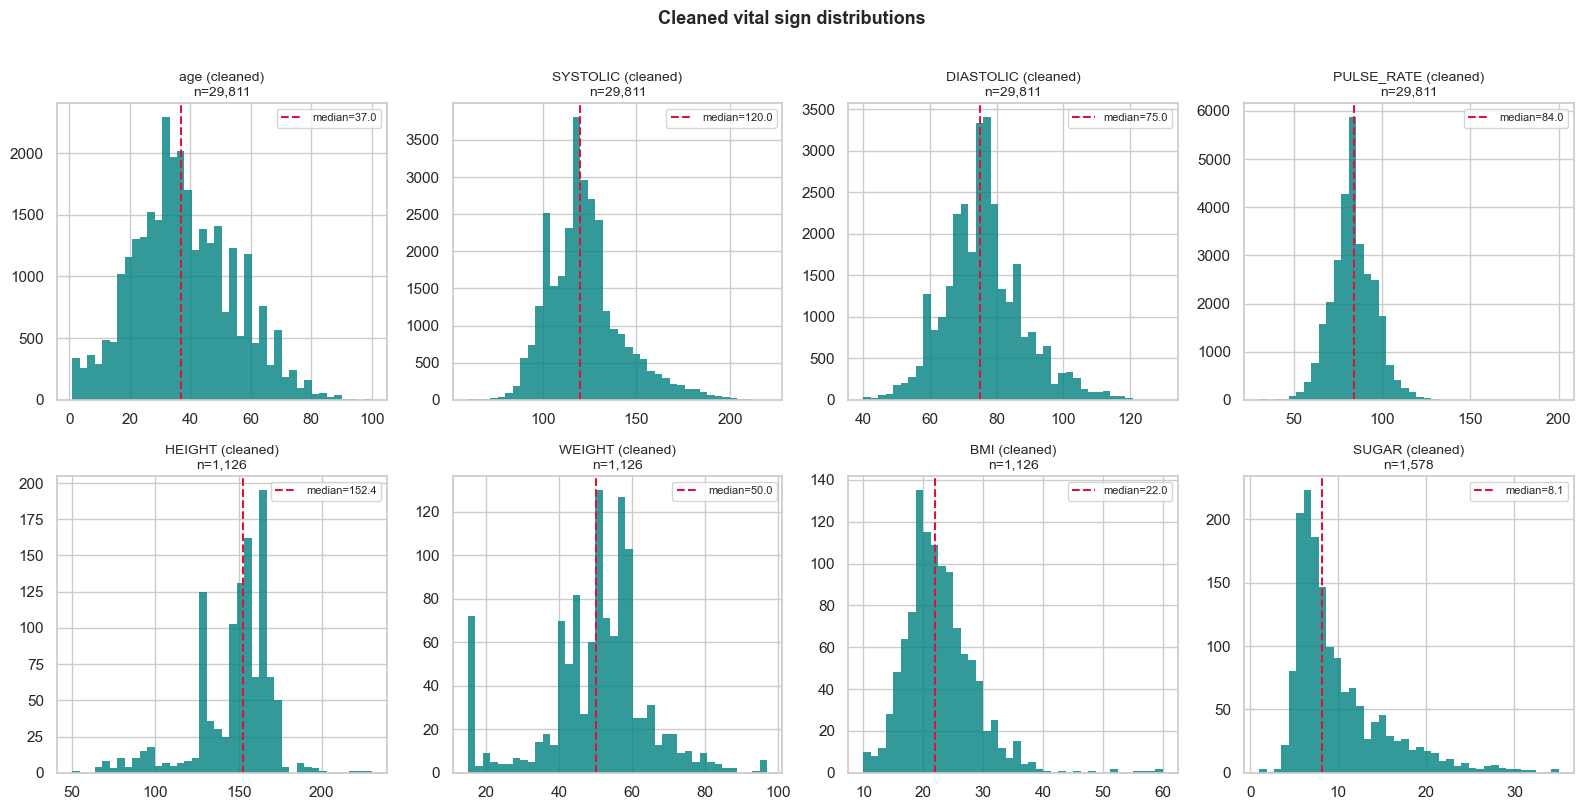

In [44]:
# Final distributions of cleaned vitals
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
clean_vitals = ['age', 'SYSTOLIC', 'DIASTOLIC', 'PULSE_RATE',
                'HEIGHT', 'WEIGHT', 'BMI', 'SUGAR']

for i, col in enumerate(clean_vitals):
    data = df_clean[col].dropna()
    axes[i].hist(data, bins=40, color='teal', edgecolor='none', alpha=0.8)
    axes[i].set_title(f'{col} (cleaned)\nn={len(data):,}', fontsize=10)
    axes[i].axvline(data.median(), color='crimson', linewidth=1.5, linestyle='--',
                    label=f'median={data.median():.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Cleaned vital sign distributions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [45]:
# Save cleaned dataset
output_path = 'test-dataset-cleaned.xlsx'
df_clean.to_excel(output_path, index=False)
print(f'Cleaned dataset saved to: {output_path}')
print(f'Final shape: {df_clean.shape}')


Cleaned dataset saved to: test-dataset-cleaned.xlsx
Final shape: (29811, 36)


## Summary of all preprocessing steps applied

| # | Issue | Action |
|---|-------|--------|
| 1 | Redundant index `Unnamed: 0` | Dropped |
| 2 | Constant column `is_poor` (all 0) | Dropped |
| 3 | `MUAC` / `RESULT_STAT_MUAC` (99.75% missing) | Dropped |
| 4 | PII name columns (`profile_name`, `father_name`, `mother_name`) | Dropped |
| 5 | Birthday time-component noise (mixed timezone offsets) | Normalized to date-only |
| 6 | Age/birthday mismatch (all rows) | Recomputed age from birthday with reference date |
| 7 | Biologically impossible ages (0 and >100) | Rows removed |
| 8 | Clinical vital outliers (fatal/impossible values) | Clipped to medically plausible ranges |
| 9 | `disabilities_name` sentinel "0" | Replaced with NaN |
| 10 | `total_income` ordinal text | Encoded as integer 0–3 |
| 11 | Inconsistent boolean encoding (True/False vs 0/1) | Standardized to 0/1 |
| 12 | Gender as text | Binary-encoded (0=Male, 1=Female) |
| 13 | Inconsistent `RESULT_STAT_SUGAR` labels | Standardized casing/format |
| 14 | High-missingness vitals (HEIGHT, WEIGHT, BMI, SUGAR, SPO2) | Added `_measured` indicator columns |
| 15 | Moderate-missingness vitals (BP, Pulse, ~8%) | Imputed with gender-stratified median |
| 16 | No age grouping feature | Added `age_group` categorical |
| 17 | `RESULT_STAT_BP` based on pre-clipped values | Recomputed from cleaned SYSTOLIC/DIASTOLIC |
